In [59]:
import glob
import os
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor
import xgboost as xgb

In [ ]:
CSV_FOLDER = "./features"
csv_files = glob.glob(os.path.join(CSV_FOLDER, "*.csv"))
conn = sqlite3.connect(":memory:")

for path in csv_files:
    file_name = os.path.splitext(os.path.basename(path))[0]
    df = pd.read_csv(path)[["NPA", "2023"]].rename(columns={"2023": file_name})
    df.to_sql(file_name, conn, index=False, if_exists="replace")
 
table_names = [os.path.splitext(os.path.basename(p))[0] for p in csv_files]
query = f'SELECT * FROM "{table_names[0]}"'

for table in table_names[1:]:
    query = f"""
    SELECT * FROM ({query.strip()})
    LEFT JOIN "{table}" USING(NPA)
    """
 
merged = pd.read_sql(query, conn)
conn.close()

merged.to_csv("merged_output.csv", index=False)

,NPA,Bicycle Friendliness,Employment,Food and Nutrition Services,High Speed Internet Access,Home Ownership,Home Sales Price,Household Income,Housing Assistance – Development-Based,Housing Code Violations,...,Proximity to Early Care and Education,Proximity to Financial Services,Proximity to Public Outdoor Recreation,Proximity to School-Age Care,Rental Costs,Single-Family Housing,Test Proficiency - Elementary School,Test Proficiency - High School,Test Proficiency - Middle School,Tree Canopy
0,2,2,95.6%,23.4%,78.7%,40.3%,"$488,364","$75,084",4.4%,1,...,37.8%,24.5%,59.1%,79.4%,"$1,252",44.6%,35.8%,13.3%,43.1%,38.1%
1,3,2,97.4%,2.9%,92.3%,39.2%,"$667,092","$117,630",3.9%,0,...,89.4%,100%,91.5%,79.7%,"$1,883",16.4%,91.3%,92.5%,87.5%,23.1%
2,4,2,94.3%,0.3%,92.9%,100%,"$1,493,043","$250,001",0%,0,...,41.6%,15.2%,1.5%,39.9%,--,89.2%,94.3%,76.9%,80%,59.5%
3,5,2,82.8%,49.7%,50.3%,14.9%,"$255,031","$49,539",0%,3,...,99.4%,19%,100%,99.4%,"$1,179",54.3%,15.4%,16.7%,25.9%,41%
4,6,2,100%,39.3%,52.2%,37.3%,"$445,698","$37,907",0%,2,...,100%,69.9%,79.8%,97.3%,"$1,065",83%,40.4%,33.3%,23.8%,34.8%


In [61]:
df = pd.read_csv("merged_output.csv").drop(columns=["NPA"])
 
def clean_col(series):
    s = series.replace("--", np.nan)
    s = s.astype(str).str.replace(r"[$,%]", "", regex=True).str.replace(",", "")
    return pd.to_numeric(s, errors="coerce")
 
for col in df.columns:
    df[col] = clean_col(df[col])
 
target_cols = ["Test Proficiency - Elementary School", "Test Proficiency - Middle School", "Test Proficiency - High School"]
df = df.dropna(subset=target_cols, how="all")
df["Test Proficiency - K12"] = df[target_cols].mean(axis=1)
 
print(df["Test Proficiency - K12"].describe().round(2))

count    455.00
mean      47.22
std       22.00
min        7.73
25%       30.38
50%       40.20
75%       65.92
max       95.33
Name: Test Proficiency - K12, dtype: float64


In [62]:
feature_cols = [
    col for col in df.columns
    if col not in ["Test Proficiency - K12"] + target_cols
]
model_df = df[feature_cols + ["Test Proficiency - K12"]].dropna(subset=["Test Proficiency - K12"])
 
X = model_df[feature_cols]
y = model_df["Test Proficiency - K12"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
numeric_features = X.columns.tolist()
 
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features)
    ],
    remainder="drop",
)
 
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_features)
    ],
    remainder="drop",
)

In [64]:
pipelines = {
    "Linear Regression": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", LinearRegression()),
    ]),
    "SVR": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", SVR(kernel="rbf", C=10.0, epsilon=0.1)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(n_estimators=300, random_state=42)),
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            n_estimators=300,
            learning_rate=0.1,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
        )),
    ]),
}

In [65]:
results = []
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "RMSE": rmse,
        "MAE": mean_absolute_error(y_test, y_pred),
    })
 
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
display(results_df)

,Model,R2,RMSE,MAE
2,Random Forest,0.788660,9.423360,7.041374
3,XGBoost,0.787403,9.451346,7.278017
1,SVR,0.764941,9.938108,7.409165
0,Linear Regression,0.751072,10.227080,7.996898


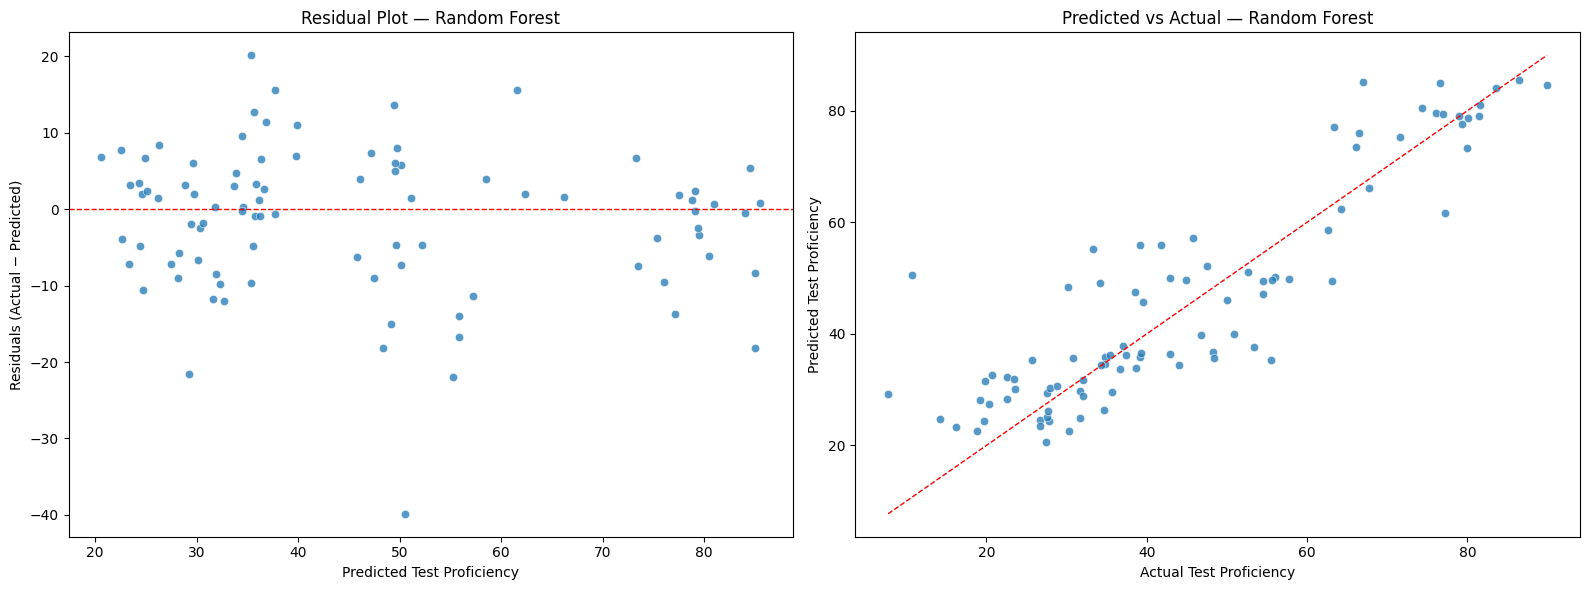

In [66]:
best_name = results_df.iloc[0]["Model"]
best_pipeline = pipelines[best_name]
best_pred = best_pipeline.predict(X_test)
residuals = y_test - best_pred
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
sns.scatterplot(x=best_pred, y=residuals, ax=axes[0], alpha=0.75)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title(f"Residual Plot — {best_name}")
axes[0].set_xlabel("Predicted Test Proficiency")
axes[0].set_ylabel("Residuals (Actual − Predicted)")
 
sns.scatterplot(x=y_test, y=best_pred, ax=axes[1], alpha=0.75)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[1].plot(lims, lims, color="red", linestyle="--", linewidth=1)
axes[1].set_title(f"Predicted vs Actual — {best_name}")
axes[1].set_xlabel("Actual Test Proficiency")
axes[1].set_ylabel("Predicted Test Proficiency")
 
plt.tight_layout()
plt.show()

In [67]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
 
for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "R2": "r2",
            "RMSE": "neg_root_mean_squared_error",
        },
        n_jobs=-1,
    )
    cv_results.append({
        "Model": name,
        "CV R2 Mean": scores["test_R2"].mean(),
        "CV R2 Std": scores["test_R2"].std(),
        "CV RMSE Mean": (-scores["test_RMSE"]).mean(),
        "CV RMSE Std": (-scores["test_RMSE"]).std()
    })
 
cv_results_df = pd.DataFrame(cv_results).sort_values("CV R2 Mean", ascending=False)
display(cv_results_df)

,Model,CV R2 Mean,CV R2 Std,CV RMSE Mean,CV RMSE Std
2,Random Forest,0.847118,0.028571,8.634672,0.955415
3,XGBoost,0.837038,0.027299,8.925854,0.913366
1,SVR,0.720158,0.041764,11.692886,0.958712
0,Linear Regression,0.649895,0.131501,12.869617,2.111106


                             Feature  Importance
2   num__Food and Nutrition Services    0.865560
4                num__Home Ownership    0.018688
11           num__Population - Youth    0.018577
19        num__Single-Family Housing    0.012994
6              num__Household Income    0.011188
1                    num__Employment    0.007270
18                 num__Rental Costs    0.006717
13      num__Proximity to a Pharmacy    0.006697
20                  num__Tree Canopy    0.006500
3    num__High Speed Internet Access    0.006233
                                 Feature  Importance
2       num__Food and Nutrition Services    0.495469
6                  num__Household Income    0.259909
15  num__Proximity to Financial Services    0.028848
4                    num__Home Ownership    0.024160
10              num__Nuisance Violations    0.022175
20                      num__Tree Canopy    0.021789
11               num__Population - Youth    0.018369
13          num__Proximity to a Pharm

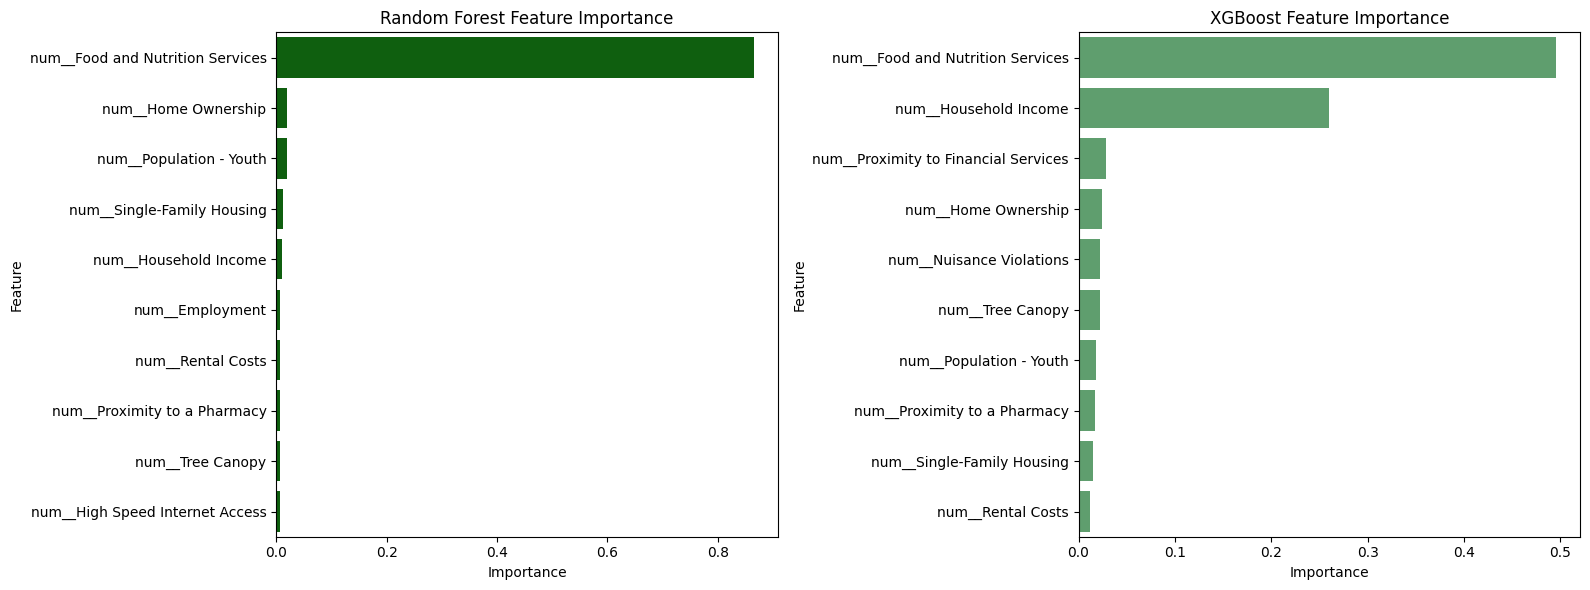

In [68]:
def get_feature_importance(model_name):
    pipeline = pipelines[model_name]
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances  = pipeline.named_steps["model"].feature_importances_
    return pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=False)
 
rf_importance  = get_feature_importance("Random Forest")
xgb_importance = get_feature_importance("XGBoost")
 
print(rf_importance.head(10))
print(xgb_importance.head(10))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
sns.barplot(data=rf_importance.head(10), x="Importance", y="Feature", ax=axes[0], color="#026C02")
sns.barplot(data=xgb_importance.head(10), x="Importance", y="Feature", ax=axes[1], color="#55A868")
axes[0].set_title("Random Forest Feature Importance")
axes[1].set_title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [69]:
feature_name = 'Food and Nutrition Services'
target_name = 'Test Proficiency - K12'
pearson_corr = model_df[feature_name].corr(model_df[target_name])
print(f"Pearson correlation ({feature_name} vs {target_name}): {pearson_corr:.3f}")

feature_name = 'Household Income'
pearson_corr = model_df[feature_name].corr(model_df[target_name])
print(f"Pearson correlation ({feature_name} vs {target_name}): {pearson_corr:.3f}")

cross1_name = 'Food and Nutrition Services'
cross2_name = 'Household Income'
pearson_corr = model_df[cross1_name].corr(model_df[cross2_name])
print(f"Pearson correlation ({cross1_name} vs {cross2_name}): {pearson_corr:.3f}")

Pearson correlation (Food and Nutrition Services vs Test Proficiency - K12): -0.735
Pearson correlation (Household Income vs Test Proficiency - K12): 0.782
Pearson correlation (Food and Nutrition Services vs Household Income): -0.665


In [70]:
drop1 = ["Food and Nutrition Services"]
X_train_w1 = X_train.drop(columns=drop1)
X_test_w1 = X_test.drop(columns=drop1)
feats_w1 = X_train_w1.columns.tolist()
 
scaled_pre_w1 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), feats_w1)
])
tree_pre_w1 = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), feats_w1)
])
 
y_bins = pd.qcut(y_train, q=5, labels=False, duplicates="drop")
cv_w1  = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X_train_w1, y_bins))
 
pipelines_w1 = {
    "Linear Regression": Pipeline([("preprocessor", scaled_pre_w1), ("model", LinearRegression())]),
    "SVR": Pipeline([("preprocessor", scaled_pre_w1), ("model", SVR())]),
    "Random Forest": Pipeline([("preprocessor", tree_pre_w1),   ("model", RandomForestRegressor(random_state=42))]),
    "XGBoost": Pipeline([("preprocessor", tree_pre_w1),   ("model", xgb.XGBRegressor(random_state=42, n_estimators=200, learning_rate=0.05))]),
}
 
rows_w1 = []
for name, pipe in pipelines_w1.items():
    s = cross_validate(pipe, X_train_w1, y_train, cv=cv_w1,
                       scoring={"R2": "r2", "RMSE": "neg_root_mean_squared_error"})
    rows_w1.append({
        "Model": name,
        "CV R2 Mean": s["test_R2"].mean(),
        "CV R2 Std": s["test_R2"].std(),
        "CV RMSE Mean": (-s["test_RMSE"]).mean(),
        "CV RMSE Std": (-s["test_RMSE"]).std(),
    })
 
results_w1 = pd.DataFrame(rows_w1).sort_values("CV R2 Mean", ascending=False)
print(results_w1)
 
best_w1 = pipelines_w1[results_w1.iloc[0]["Model"]]
best_w1.fit(X_train_w1, y_train)
y_pred_w1 = best_w1.predict(X_test_w1)
print(f"Best model (no Food/Nutrition): {results_w1.iloc[0]['Model']}")
print(f"Test R2:   {r2_score(y_test, y_pred_w1):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_w1)):.3f}")

               Model  CV R2 Mean  CV R2 Std  CV RMSE Mean  CV RMSE Std
0  Linear Regression    0.631666   0.046021     13.473537     0.691314
2      Random Forest    0.625842   0.045048     13.603901     0.968566
3            XGBoost    0.600025   0.042980     14.078432     1.060508
1                SVR    0.352871   0.051281     17.892269     0.671004
Best model (no Food/Nutrition): Linear Regression
Test R2:   0.684
Test RMSE: 11.527


In [71]:
lr_w1 = pipelines_w1["Linear Regression"]
lr_w1.fit(X_train_w1, y_train)
lr_w1_pred = lr_w1.predict(X_test_w1)
coef_df_w1 = pd.DataFrame({
    "Feature": lr_w1.named_steps["preprocessor"].get_feature_names_out(),
    "Coefficient": lr_w1.named_steps["model"].coef_,
}).sort_values("Coefficient", key=lambda s: s.abs(), ascending=False)
print(f"\nLinear Regression (no Food/Nutrition)")
print(coef_df_w1.head(15))


Linear Regression (no Food/Nutrition)
                                        Feature  Coefficient
5                         num__Household Income    10.487039
3                           num__Home Ownership     5.575918
14         num__Proximity to Financial Services     3.416337
19                             num__Tree Canopy     3.399836
18                   num__Single-Family Housing    -2.913066
13   num__Proximity to Early Care and Education    -1.831369
15  num__Proximity to Public Outdoor Recreation     1.818265
17                            num__Rental Costs     1.808158
9                      num__Nuisance Violations    -1.402915
1                               num__Employment     1.219128
0                     num__Bicycle Friendliness     0.897609
2               num__High Speed Internet Access     0.733784
12                 num__Proximity to a Pharmacy     0.708275
7                  num__Housing Code Violations    -0.678792
10                      num__Population - Yout

               Model  CV R2 Mean  CV R2 Std  CV RMSE Mean  CV RMSE Std
2      Random Forest    0.566642   0.044335     14.638462     0.768743
0  Linear Regression    0.538911   0.066341     15.055437     0.845988
3            XGBoost    0.537766   0.061747     15.103980     0.947280
1                SVR    0.260553   0.052858     19.130789     0.681384
Best model (no Food/Nutrition or Income): Random Forest
Test R2: 0.620
Test RMSE: 12.642


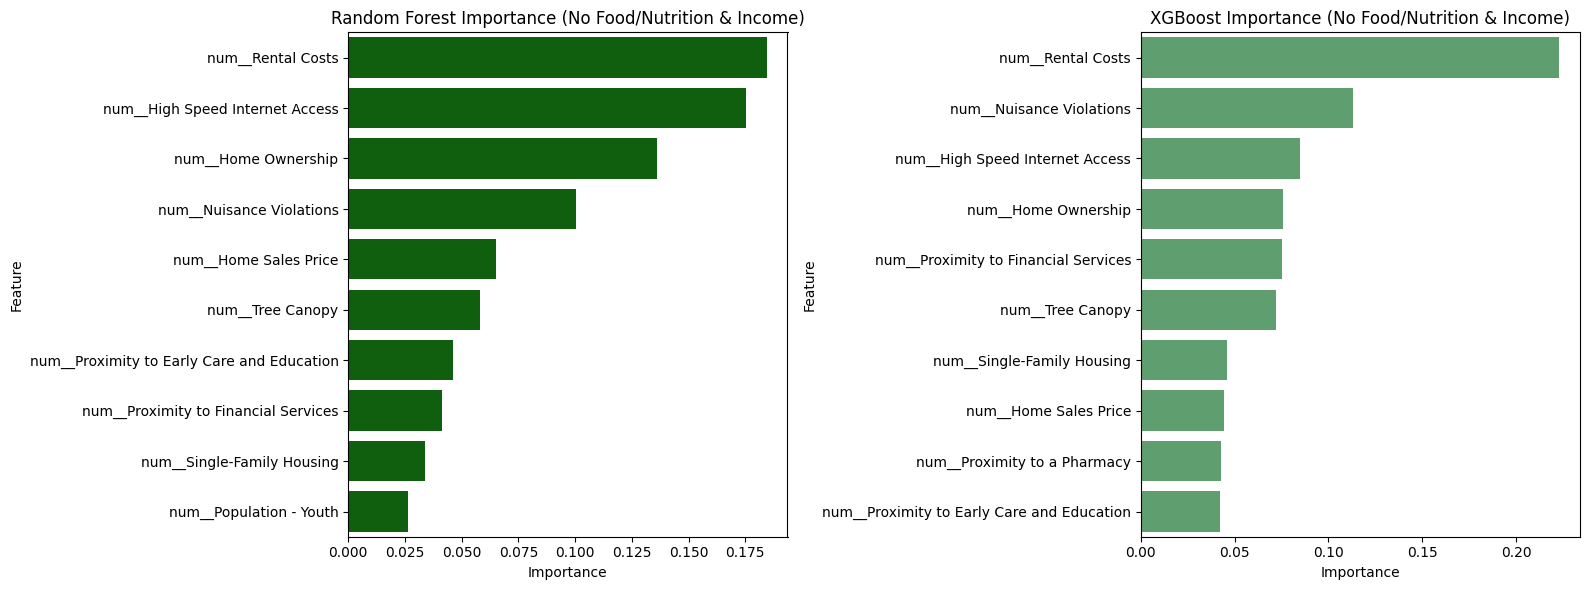

In [72]:
drop2 = ["Food and Nutrition Services", "Household Income"]
X_train_w2 = X_train.drop(columns=drop2)
X_test_w2 = X_test.drop(columns=drop2)
feats_w2 = X_train_w2.columns.tolist()
 
scaled_pre_w2 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), feats_w2)
])
tree_pre_w2 = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), feats_w2)
])
 
y_bins2 = pd.qcut(y_train, q=5, labels=False, duplicates="drop")
cv_w2   = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X_train_w2, y_bins2))
 
pipelines_w2 = {
    "Linear Regression": Pipeline([("preprocessor", scaled_pre_w2), ("model", LinearRegression())]),
    "SVR": Pipeline([("preprocessor", scaled_pre_w2), ("model", SVR())]),
    "Random Forest": Pipeline([("preprocessor", tree_pre_w2),   ("model", RandomForestRegressor(random_state=42))]),
    "XGBoost": Pipeline([("preprocessor", tree_pre_w2),   ("model", xgb.XGBRegressor(random_state=42, n_estimators=200, learning_rate=0.05))]),
}
 
rows_w2 = []
for name, pipe in pipelines_w2.items():
    s = cross_validate(pipe, X_train_w2, y_train, cv=cv_w2,
                       scoring={"R2": "r2", "RMSE": "neg_root_mean_squared_error"})
    rows_w2.append({
        "Model": name,
        "CV R2 Mean": s["test_R2"].mean(),
        "CV R2 Std": s["test_R2"].std(),
        "CV RMSE Mean": (-s["test_RMSE"]).mean(),
        "CV RMSE Std": (-s["test_RMSE"]).std(),
    })
 
results_w2 = pd.DataFrame(rows_w2).sort_values("CV R2 Mean", ascending=False)
print(results_w2)
 
best_w2 = pipelines_w2[results_w2.iloc[0]["Model"]]
best_w2.fit(X_train_w2, y_train)
y_pred_w2 = best_w2.predict(X_test_w2)
print(f"Best model (no Food/Nutrition or Income): {results_w2.iloc[0]['Model']}")
print(f"Test R2: {r2_score(y_test, y_pred_w2):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_w2)):.3f}")
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
for ax, model_name, color in zip(axes, ["Random Forest", "XGBoost"], ["#026C02", "#55A868"]):
    pipe = pipelines_w2[model_name]
    pipe.fit(X_train_w2, y_train)
    imp_df = pd.DataFrame({
        "Feature": pipe.named_steps["preprocessor"].get_feature_names_out(),
        "Importance": pipe.named_steps["model"].feature_importances_,
    }).sort_values("Importance", ascending=False)
    sns.barplot(data=imp_df.head(10), x="Importance", y="Feature", ax=ax, color=color)
    ax.set_title(f"{model_name} Importance (No Food/Nutrition & Income)")
plt.tight_layout()
plt.show()